# Decision Trees and Random Forests

## Classification Models  




In [42]:

# Core data manipulation libraries
import numpy as np                    # Numerical computing
import pandas as pd                   # Data manipulation and analysis

# Visualization libraries
import matplotlib.pyplot as plt       # Basic plotting
import seaborn as sns                 # Statistical visualization

# Scikit-learn: Machine Learning library
from sklearn.datasets import load_wine           # Wine dataset (multi-class)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Tree-based models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)

# Set random seed for reproducibility
np.random.seed(42)


print("DecisionTreeClassifier ( Single decision tree model)")
print("RandomForestClassifier  (Ensemble of decision trees)")
print("plot tree (Visualize decision tree structure)")
print("GridSearchCV (Hyperparameter tuning)")

DecisionTreeClassifier ( Single decision tree model)
RandomForestClassifier  (Ensemble of decision trees)
plot tree (Visualize decision tree structure)
GridSearchCV (Hyperparameter tuning)


In [43]:
# Load the wine dataset from sklearn
wine = load_wine()

# Create a DataFrame for easier manipulation
# wine.data contains the features, wine.feature_names has column names
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Add the target variable (wine class: 0, 1, or 2)
df['target'] = wine.target

# Map target numbers to meaningful names
target_names = {0: 'Class_0', 1: 'Class_1', 2: 'Class_2'}
df['wine_class'] = df['target'].map(target_names)

# Display dataset information
print("DATASET LOADED")

print(f"Dataset Shape: {df.shape[0]} samples × {df.shape[1]} columns")
print(f"Target Classes: {wine.target_names}")
print(f"Features ({len(wine.feature_names)}):")
for i, name in enumerate(wine.feature_names, 1):
    print(f"   {i:2d}. {name}")

df.head()

DATASET LOADED
Dataset Shape: 178 samples × 15 columns
Target Classes: ['class_0' 'class_1' 'class_2']
Features (13):
    1. alcohol
    2. malic_acid
    3. ash
    4. alcalinity_of_ash
    5. magnesium
    6. total_phenols
    7. flavanoids
    8. nonflavanoid_phenols
    9. proanthocyanins
   10. color_intensity
   11. hue
   12. od280/od315_of_diluted_wines
   13. proline


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Class_0


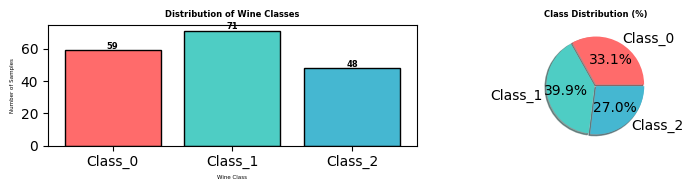

Class Distribution Summary:
wine_class
Class_0    59
Class_1    71
Class_2    48


In [44]:
# Count samples per class
class_counts = df['wine_class'].value_counts().sort_index()

# Create a bar plot
fig, axes = plt.subplots(1, 2, figsize=(8, 2))

# Bar chart
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Wine Class', fontsize=4)
axes[0].set_ylabel('Number of Samples', fontsize=4)
axes[0].set_title('Distribution of Wine Classes', fontsize=6, fontweight='bold')

# Add count labels on bars
for i, (idx, val) in enumerate(zip(class_counts.index, class_counts.values)):
    axes[0].text(i, val + 1, str(val), ha='center', fontsize=6, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, explode=[0.02, 0.02, 0.02], shadow=True)
axes[1].set_title('Class Distribution (%)', fontsize=6, fontweight='bold')

plt.tight_layout()
plt.show()

print("Class Distribution Summary:")
print(class_counts.to_string())


In [45]:
# Separate features and target
X = df[wine.feature_names]  # All feature columns
y = df['target']            # Target column (0, 1, or 2)

# Split into training (80%) and testing (20%) sets
# stratify=y ensures each class is proportionally represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class proportions
)


print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Number of features: {X_train.shape[1]}")

print("Class distribution in splits:")
print(f"Training: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Testing:  {dict(zip(*np.unique(y_test, return_counts=True)))}")

Training set: 142 samples (80%)
Testing set:  36 samples (20%)
Number of features: 13
Class distribution in splits:
Training: {np.int64(0): np.int64(47), np.int64(1): np.int64(57), np.int64(2): np.int64(38)}
Testing:  {np.int64(0): np.int64(12), np.int64(1): np.int64(14), np.int64(2): np.int64(10)}


---

## ABOUT DECISION TREES

Decision Trees learn if-then rules from data by recursively splitting the dataset



In [46]:
# Note: No max_depth means the tree will grow until all leaves are pure
dt_basic = DecisionTreeClassifier(
    random_state=42,      # For reproducibility
    criterion='gini'      # Use Gini impurity for splits (default)
)

# Train the model on our training data
dt_basic.fit(X_train, y_train)

# Make predictions on training and test sets
y_train_pred = dt_basic.predict(X_train)
y_test_pred = dt_basic.predict(X_test)

# Calculate accuracy scores
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("TRAINED BASIC DESICION TREE")

print(f"Depth: {dt_basic.get_depth()}")
print(f"Number of leaves: {dt_basic.get_n_leaves()}")
print(f"Number of features used: {dt_basic.n_features_in_}")

print(f"Accuracy Results:")
print(f"Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Testing Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")

# Check for overfitting
if train_acc == 1.0 and test_acc < 0.95:       ### APPLIED CONDITION TO CHECH IF THE MODEL IS OVERFITTING
    print("100% training accuracy with lower test accuracy")          
    print("the tree memorized the training data")

TRAINED BASIC DESICION TREE
Depth: 4
Number of leaves: 8
Number of features used: 13
Accuracy Results:
Training Accuracy: 1.0000 (100.00%)
Testing Accuracy:  0.9444 (94.44%)
100% training accuracy with lower test accuracy
the tree memorized the training data


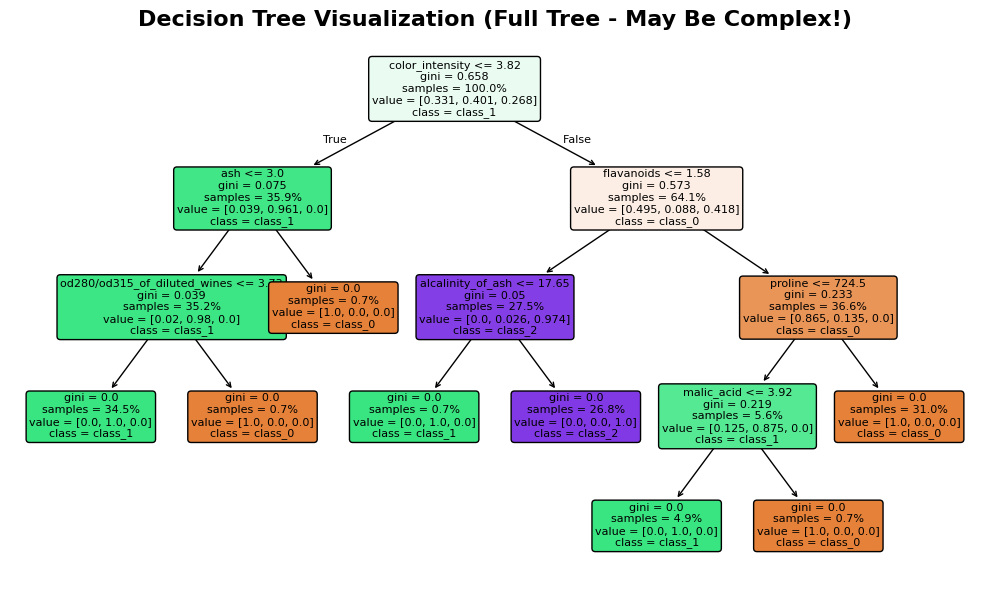

How to Read the Tree:
Each box shows: feature ≤ threshold
'gini': Impurity measure (0 = pure node)
'samples': Percentage of training samples at this node
'value': Distribution of classes [Class_0, Class_1, Class_2]
'class': Predicted class if this were a leaf node
Colors: Darker = more pure (confident prediction)


In [47]:
# One of the biggest advantages of Decision Trees: interpretability!


# Create a figure for the tree visualization
plt.figure(figsize=(10, 6))

# Plot the decision tree
plot_tree(
    dt_basic,                          # Our trained tree
    feature_names=wine.feature_names,  # Feature names for readability
    class_names=wine.target_names,     # Class names
    filled=True,                       # Color nodes by class
    rounded=True,                      # Rounded corners
    fontsize=8,                        # Font size
    proportion=True                    # Show proportions instead of counts
)

plt.title('Decision Tree Visualization (Full Tree - May Be Complex!)', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("How to Read the Tree:")
print("Each box shows: feature ≤ threshold")
print("'gini': Impurity measure (0 = pure node)")
print("'samples': Percentage of training samples at this node")
print("'value': Distribution of classes [Class_0, Class_1, Class_2]")
print("'class': Predicted class if this were a leaf node")
print("Colors: Darker = more pure (confident prediction)")

SIMPLE DECISION TREE (max_depth=3)
   • Depth: 3
   • Number of leaves: 7
Accuracy Comparison:
Full Tree   Simple Tree
Training:100.00%        99.30%
Testing: 94.44%        94.44%


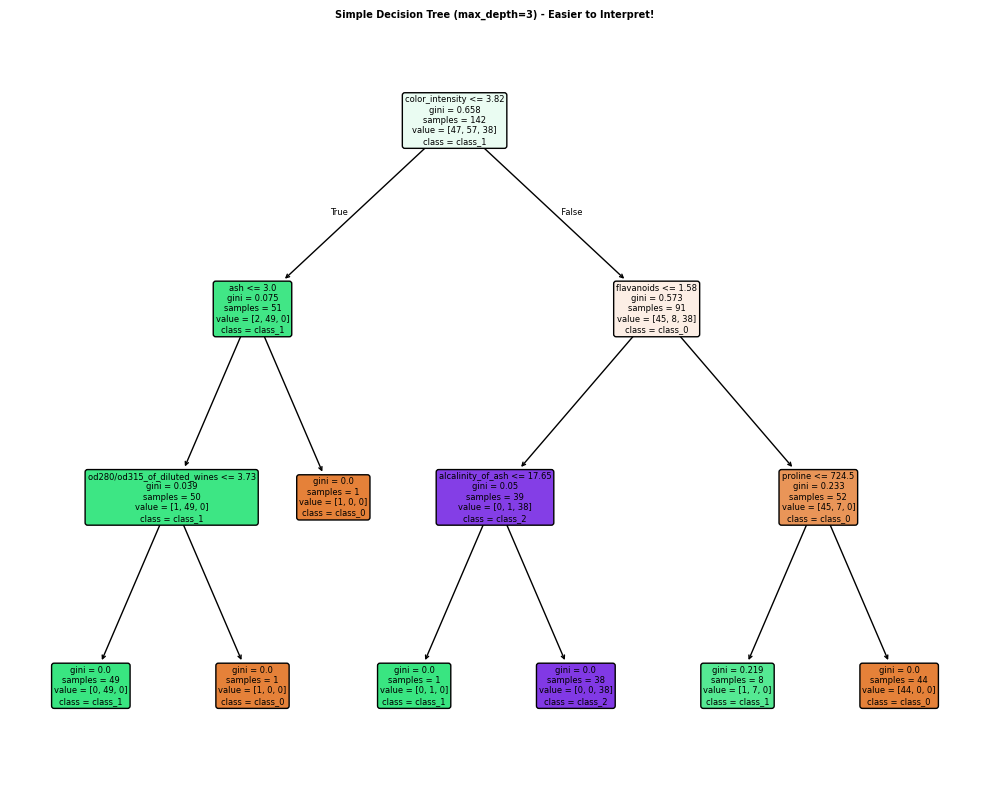

In [48]:

# Create a Decision Tree with limited depth
dt_simple = DecisionTreeClassifier(
    max_depth=3,          # Limit tree to 3 levels
    random_state=42,
    criterion='gini'
)

# Train the model
dt_simple.fit(X_train, y_train)

# Make predictions
y_train_pred_simple = dt_simple.predict(X_train)
y_test_pred_simple = dt_simple.predict(X_test)

# Calculate accuracy
train_acc_simple = accuracy_score(y_train, y_train_pred_simple)
test_acc_simple = accuracy_score(y_test, y_test_pred_simple)

print("SIMPLE DECISION TREE (max_depth=3)")
print(f"   • Depth: {dt_simple.get_depth()}")
print(f"   • Number of leaves: {dt_simple.get_n_leaves()}")

print(f"Accuracy Comparison:")
print(f"Full Tree   Simple Tree")
print(f"Training:{train_acc*100:6.2f}%       {train_acc_simple*100:6.2f}%")
print(f"Testing:{test_acc*100:6.2f}%       {test_acc_simple*100:6.2f}%")

# Visualize the simpler tree
plt.figure(figsize=(10, 8))
plot_tree(
    dt_simple,
    feature_names=wine.feature_names,
    class_names=wine.target_names,
    filled=True,
    rounded=True,
    fontsize=6
)
plt.title('Simple Decision Tree (max_depth=3) - Easier to Interpret!', 
          fontsize=7, fontweight='bold')
plt.tight_layout()
plt.show()

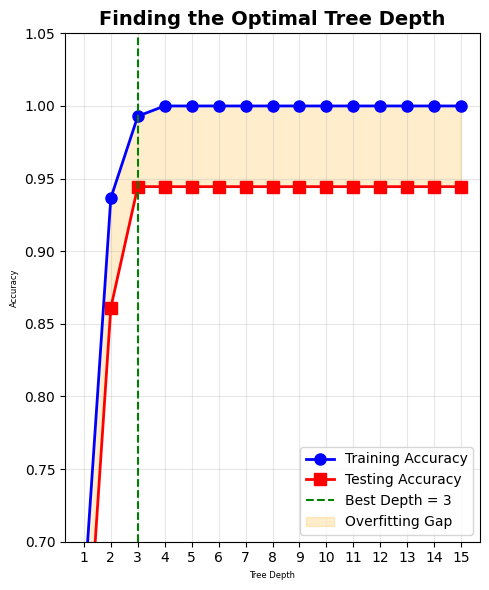

Optimal Tree Depth: 3
Best Test Accuracy: 94.44%
Observation: Notice how training accuracy keeps increasing with depth,
but test accuracy plateaus or decreases - this is OVERFITTING!


In [49]:
# Test depths from 1 to 15
depths = range(1, 16)
train_scores = []
test_scores = []

for depth in depths:
    # Create and train tree with this depth
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    # Record scores
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test, dt.predict(X_test)))

# Find best depth based on test accuracy
best_depth = depths[np.argmax(test_scores)]
best_test_acc = max(test_scores)

# Plot the results
plt.figure(figsize=(5, 6))
plt.plot(depths, train_scores, 'b-o', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(depths, test_scores, 'r-s', label='Testing Accuracy', linewidth=2, markersize=8)

# Mark the best depth
plt.axvline(x=best_depth, color='green', linestyle='--', label=f'Best Depth = {best_depth}')

# Shade overfitting region
plt.fill_between(depths, train_scores, test_scores, alpha=0.2, color='orange',
                 label='Overfitting Gap')

plt.xlabel('Tree Depth', fontsize=6)
plt.ylabel('Accuracy', fontsize=6)
plt.title('Finding the Optimal Tree Depth', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.ylim(0.7, 1.05)
plt.tight_layout()
plt.show()

print(f"Optimal Tree Depth: {best_depth}")
print(f"Best Test Accuracy: {best_test_acc*100:.2f}%")
print("Observation: Notice how training accuracy keeps increasing with depth,")
print("but test accuracy plateaus or decreases - this is OVERFITTING!")

## Random Forests



In [50]:
# Create a Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=100,     # Number of trees in the forest
    max_depth=None,       # Let trees grow fully
    min_samples_split=2,  # Minimum samples to split a node
    min_samples_leaf=1,   # Minimum samples in a leaf
    random_state=42,      # For reproducibility
    n_jobs=-1             # Use all CPU cores for parallel training
)

# Train the Random Forest
print("Training Random Forest with 100 trees...")
rf.fit(X_train, y_train)
print("Training complete!")

# Make predictions
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

# Calculate accuracy
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)

print("RANDOM FOREST RESULTS")
print(f"Forest Properties:")
print(f"Number of trees: {rf.n_estimators}")
print(f"Features per tree: {rf.n_features_in_}")

print(f"Accuracy:")
print(f"Training Accuracy: {train_acc_rf:.4f} ({train_acc_rf*100:.2f}%)")
print(f"Testing Accuracy:  {test_acc_rf:.4f} ({test_acc_rf*100:.2f}%)")

Training Random Forest with 100 trees...
Training complete!
RANDOM FOREST RESULTS
Forest Properties:
Number of trees: 100
Features per tree: 13
Accuracy:
Training Accuracy: 1.0000 (100.00%)
Testing Accuracy:  1.0000 (100.00%)


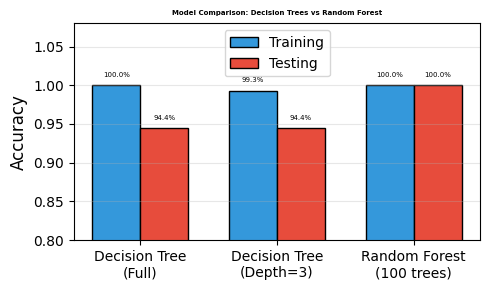

Key Observations:
Full Decision Tree: Perfect training, may overfit
Simple Decision Tree: Less overfitting, but may underfit
Random Forest: Best of both worlds - high accuracy, good generalization


In [51]:
# Collect all results
models = ['Decision Tree\n(Full)', 'Decision Tree\n(Depth=3)', 'Random Forest\n(100 trees)']
train_accs = [train_acc, train_acc_simple, train_acc_rf]
test_accs = [test_acc, test_acc_simple, test_acc_rf]

# Create comparison bar chart
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(5, 3))

bars1 = ax.bar(x - width/2, train_accs, width, label='Training', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, test_accs, width, label='Testing', color='#e74c3c', edgecolor='black')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height*100:.1f}%', ha='center', va='bottom', fontsize=5)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height*100:.1f}%', ha='center', va='bottom', fontsize=5)

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Comparison: Decision Trees vs Random Forest', fontsize=5, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0.8, 1.08)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Observations:")
print("Full Decision Tree: Perfect training, may overfit")
print("Simple Decision Tree: Less overfitting, but may underfit")
print("Random Forest: Best of both worlds - high accuracy, good generalization")

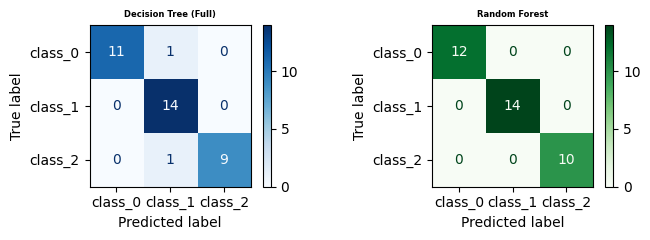

RANDOM FOREST
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [52]:
fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))

# Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm_dt, display_labels=wine.target_names).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Decision Tree (Full)', fontsize=6, fontweight='bold')

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=wine.target_names).plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest', fontsize=6, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed classification reports
print("RANDOM FOREST")
print(classification_report(y_test, y_test_pred_rf, target_names=wine.target_names))

Feature Importance

One of the most powerful aspects of tree-based models is feature importance

Feature importance tells us which features are most useful for making predictions.

How is it calculated
For each feature, measure how much it reduces impurity (Gini) across all trees
Features that create better splits have higher importance
Importance values sum to 1.0

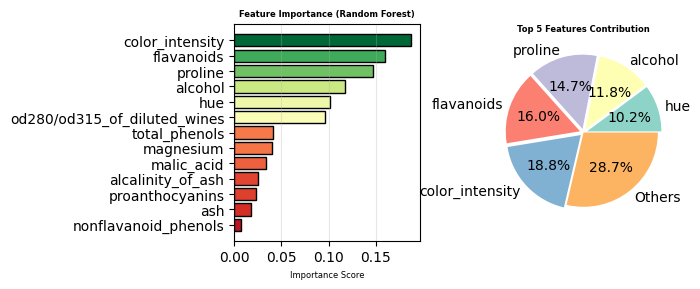

TOP 5 MOST IMPORTANT FEATURES:
   color_intensity           0.1876 ███████
   flavanoids                0.1596 ██████
   proline                   0.1468 █████
   alcohol                   0.1179 ████
   hue                       0.1015 ████


In [53]:
# Get feature importances from the Random Forest
importances = rf.feature_importances_

# Create a DataFrame for easy manipulation
feature_importance_df = pd.DataFrame({
    'Feature': wine.feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)  # Sort for horizontal bar plot

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Horizontal bar plot
colors = plt.cm.RdYlGn(feature_importance_df['Importance'] / feature_importance_df['Importance'].max())
axes[0].barh(feature_importance_df['Feature'], feature_importance_df['Importance'], 
             color=colors, edgecolor='black')
axes[0].set_xlabel('Importance Score', fontsize=6)
axes[0].set_title('Feature Importance (Random Forest)', fontsize=6, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Pie chart of top 5 features
top5 = feature_importance_df.tail(5)
others = feature_importance_df.head(len(feature_importance_df)-5)['Importance'].sum()

pie_data = list(top5['Importance']) + [others]
pie_labels = list(top5['Feature']) + ['Others']

axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', 
            colors=plt.cm.Set3.colors[:6], explode=[0.05]*5 + [0])
axes[1].set_title('Top 5 Features Contribution', fontsize=6, fontweight='bold')

plt.tight_layout()
plt.show()

# Print top 5 features
print("TOP 5 MOST IMPORTANT FEATURES:")
for i, row in feature_importance_df.tail(5).iloc[::-1].iterrows():
    bar = '█' * int(row['Importance'] * 40)
    print(f"   {row['Feature']:25s} {row['Importance']:.4f} {bar}")

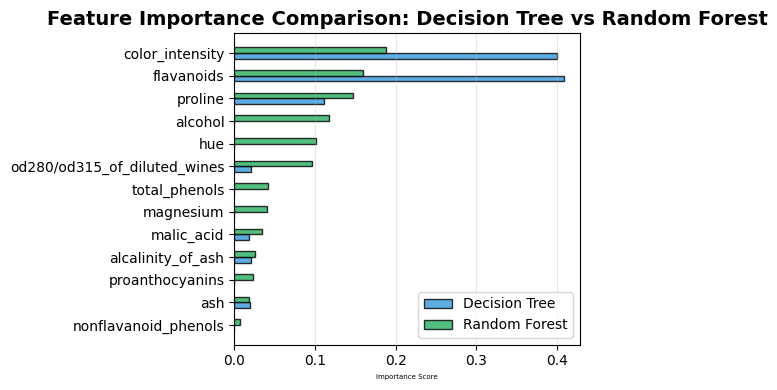

Observations:
Decision Trees may over-rely on a few features
Random Forests provide more balanced importance scores
RF importance is more stable due to averaging across many trees


In [54]:
# Get Decision Tree feature importance
dt_importances = dt_basic.feature_importances_

# Create comparison DataFrame
importance_comparison = pd.DataFrame({
    'Feature': wine.feature_names,
    'Decision Tree': dt_importances,
    'Random Forest': importances
})

# Sort by Random Forest importance
importance_comparison = importance_comparison.sort_values('Random Forest', ascending=True)

# Create comparison plot
fig, ax = plt.subplots(figsize=(6, 4))

y_pos = np.arange(len(wine.feature_names))
width = 0.25

ax.barh(y_pos - width/2, importance_comparison['Decision Tree'], width, 
        label='Decision Tree', color='#3498db', edgecolor='black', alpha=0.8)
ax.barh(y_pos + width/2, importance_comparison['Random Forest'], width, 
        label='Random Forest', color='#27ae60', edgecolor='black', alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(importance_comparison['Feature'])
ax.set_xlabel('Importance Score', fontsize=5)
ax.set_title('Feature Importance Comparison: Decision Tree vs Random Forest', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Observations:")
print("Decision Trees may over-rely on a few features")
print("Random Forests provide more balanced importance scores")
print("RF importance is more stable due to averaging across many trees")

Hyperparameter Tuning

Using GridSearchCV to find the optimal hyperparameters for our Random Forest.
Key Hyperparameters:

n_estimators: Number of trees (more = better but slower)

max_dept: Maximum depth of each tree

min_samples_split: Minimum samples required to split a node

min_samples_leaf: Minimum samples required in a leaf node

In [55]:
# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],           # Number of trees
    'max_depth': [3, 5, 10, None],            # Maximum depth
    'min_samples_split': [2, 5, 10],          # Min samples to split
    'min_samples_leaf': [1, 2, 4]             # Min samples in leaf
}

# Create a base Random Forest
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Create GridSearchCV object
# cv=5 means 5-fold cross-validation
print("Starting GridSearchCV (this may take a minute)...")
print(f"Testing {3*4*3*3} = {3*4*3*3} parameter combinations with 5-fold CV")
print(f"Total fits: {3*4*3*3*5} = {3*4*3*3*5}")

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',      # Optimize for accuracy
    n_jobs=-1,               # Use all CPU cores
    verbose=1                # Show progress
)

# Fit the grid search
grid_search.fit(X_train, y_train)

print("GridSearchCV Complete!")
print("BEST PARAMETERS FOUND:")
for param, value in grid_search.best_params_.items():
    print(f"   • {param}: {value}")

print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")

Starting GridSearchCV (this may take a minute)...
Testing 108 = 108 parameter combinations with 5-fold CV
Total fits: 540 = 540
Fitting 5 folds for each of 108 candidates, totalling 540 fits
GridSearchCV Complete!
BEST PARAMETERS FOUND:
   • max_depth: 3
   • min_samples_leaf: 1
   • min_samples_split: 2
   • n_estimators: 50
Best Cross-Validation Score: 0.9862 (98.62%)


OPTIMIZED RANDOM FOREST RESULTS
Performance:
Training Accuracy: 1.0000 (100.00%)
Testing Accuracy:  1.0000 (100.00%)
Improvement over default Random Forest:
   Same performance as default


<Figure size 800x600 with 0 Axes>

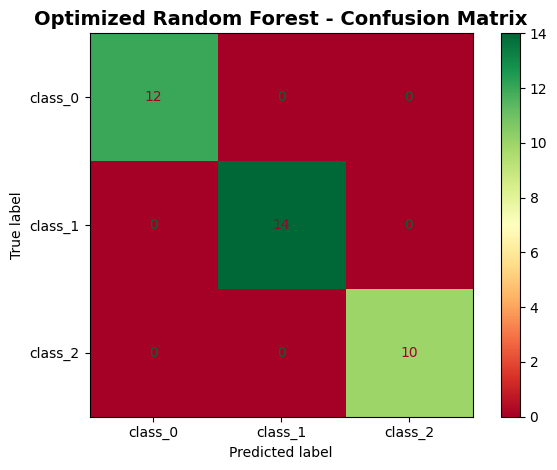


Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [56]:

# Use the best model from GridSearchCV

# Get the best estimator
best_rf = grid_search.best_estimator_

# Make predictions
y_test_pred_best = best_rf.predict(X_test)
y_train_pred_best = best_rf.predict(X_train)

# Calculate accuracy
train_acc_best = accuracy_score(y_train, y_train_pred_best)
test_acc_best = accuracy_score(y_test, y_test_pred_best)

print("OPTIMIZED RANDOM FOREST RESULTS")
print(f"Performance:")
print(f"Training Accuracy: {train_acc_best:.4f} ({train_acc_best*100:.2f}%)")
print(f"Testing Accuracy:  {test_acc_best:.4f} ({test_acc_best*100:.2f}%)")

# Compare with default RF
print(f"Improvement over default Random Forest:")
improvement = (test_acc_best - test_acc_rf) * 100
if improvement > 0:
    print(f"   Test accuracy improved by {improvement:.2f}%")
elif improvement < 0:
    print(f"   Test accuracy decreased by {abs(improvement):.2f}% (default was already good!)")
else:
    print(f"   Same performance as default")

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_best = confusion_matrix(y_test, y_test_pred_best)
ConfusionMatrixDisplay(cm_best, display_labels=wine.target_names).plot(cmap='RdYlGn')
plt.title('Optimized Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_best, target_names=wine.target_names))

Final Model Summary

FINAL MODEL COMPARISON
                    Model Training Accuracy Testing Accuracy Overfitting Gap
     Decision Tree (Full)           100.00%           94.44%           5.56%
  Decision Tree (Depth=3)            99.30%           94.44%           4.85%
  Random Forest (Default)           100.00%          100.00%           0.00%
Random Forest (Optimized)           100.00%          100.00%           0.00%


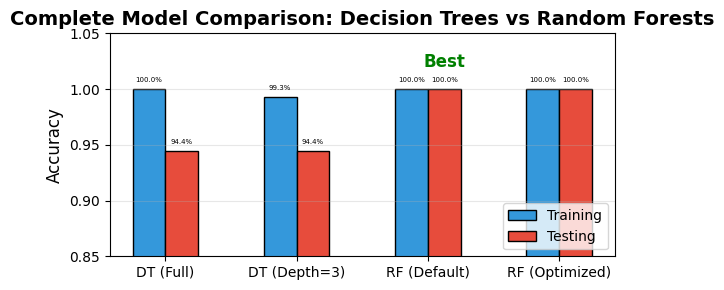

In [57]:
# Create summary DataFrame
summary_data = {
    'Model': ['Decision Tree (Full)', 'Decision Tree (Depth=3)', 
              'Random Forest (Default)', 'Random Forest (Optimized)'],
    'Training Accuracy': [train_acc, train_acc_simple, train_acc_rf, train_acc_best],
    'Testing Accuracy': [test_acc, test_acc_simple, test_acc_rf, test_acc_best],
    'Overfitting Gap': [train_acc - test_acc, train_acc_simple - test_acc_simple,
                        train_acc_rf - test_acc_rf, train_acc_best - test_acc_best]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Training Accuracy'] = summary_df['Training Accuracy'].apply(lambda x: f"{x*100:.2f}%")
summary_df['Testing Accuracy'] = summary_df['Testing Accuracy'].apply(lambda x: f"{x*100:.2f}%")
summary_df['Overfitting Gap'] = summary_df['Overfitting Gap'].apply(lambda x: f"{x*100:.2f}%")

print("FINAL MODEL COMPARISON")
print(summary_df.to_string(index=False))
# Create visualization
fig, ax = plt.subplots(figsize=(6, 3))

models = ['DT (Full)', 'DT (Depth=3)', 'RF (Default)', 'RF (Optimized)']
train_accs_all = [train_acc, train_acc_simple, train_acc_rf, train_acc_best]
test_accs_all = [test_acc, test_acc_simple, test_acc_rf, test_acc_best]

x = np.arange(len(models))
width = 0.25

bars1 = ax.bar(x - width/2, train_accs_all, width, label='Training', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, test_accs_all, width, label='Testing', color='#e74c3c', edgecolor='black')

# Add value labels
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{height*100:.1f}%', ha='center', va='bottom', fontsize=5)

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Complete Model Comparison: Decision Trees vs Random Forests', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='lower right')
ax.set_ylim(0.85, 1.05)
ax.grid(axis='y', alpha=0.3)

# Add "Best" annotation
best_idx = np.argmax(test_accs_all)
ax.annotate('Best', xy=(best_idx + width/2, test_accs_all[best_idx] + 0.02),
            fontsize=12, ha='center', fontweight='bold', color='green')

plt.tight_layout()
plt.show()

In [58]:

print("""
            KEY CONCEPTS SUMMARY                                   
         DECISION TREES                                                                                            
Learn if-then rules by recursively splitting data                        
Use Gini impurity or Entropy to find best splits              
Highly interpretable - can visualize the entire model         
Prone to overfitting if not pruned (controlled with max_depth)           
                                                                  
 RANDOM FORESTS                                            
                                           
Ensemble of many Decision Trees working together                         
Uses Bootstrap sampling + Feature randomization               
More robust, less overfitting than single trees               
Provides feature importance rankings                          
                                
FEATURE IMPORTANCE                                                       
                                           
Measures how much each feature contributes to predictions 
based on impurity reduction across all trees/splits           
Useful for feature selection and model interpretation         
                                
KEY HYPERPARAMETERS                                                     

n_estimators: Number of trees (more = better but slower)      
max_depth: Controls tree depth (prevents overfitting)                    
 min_samples_split/leaf: Controls when to stop splitting""")
                                


            KEY CONCEPTS SUMMARY                                   
         DECISION TREES                                                                                            
Learn if-then rules by recursively splitting data                        
Use Gini impurity or Entropy to find best splits              
Highly interpretable - can visualize the entire model         
Prone to overfitting if not pruned (controlled with max_depth)           
                                                                  
 RANDOM FORESTS                                            
                                           
Ensemble of many Decision Trees working together                         
Uses Bootstrap sampling + Feature randomization               
More robust, less overfitting than single trees               
Provides feature importance rankings                          
                                
FEATURE IMPORTANCE                                                       
